In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

In [5]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI ml/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/AI ml/Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Corrected base_dir to point to the extracted content
base_dir = "/content/drive/MyDrive/AI ml/Data"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)

Train path: /content/drive/MyDrive/AI ml/Data/train
Test path: /content/drive/MyDrive/AI ml/Data/test


# Task 1: Data understanding and visualization

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


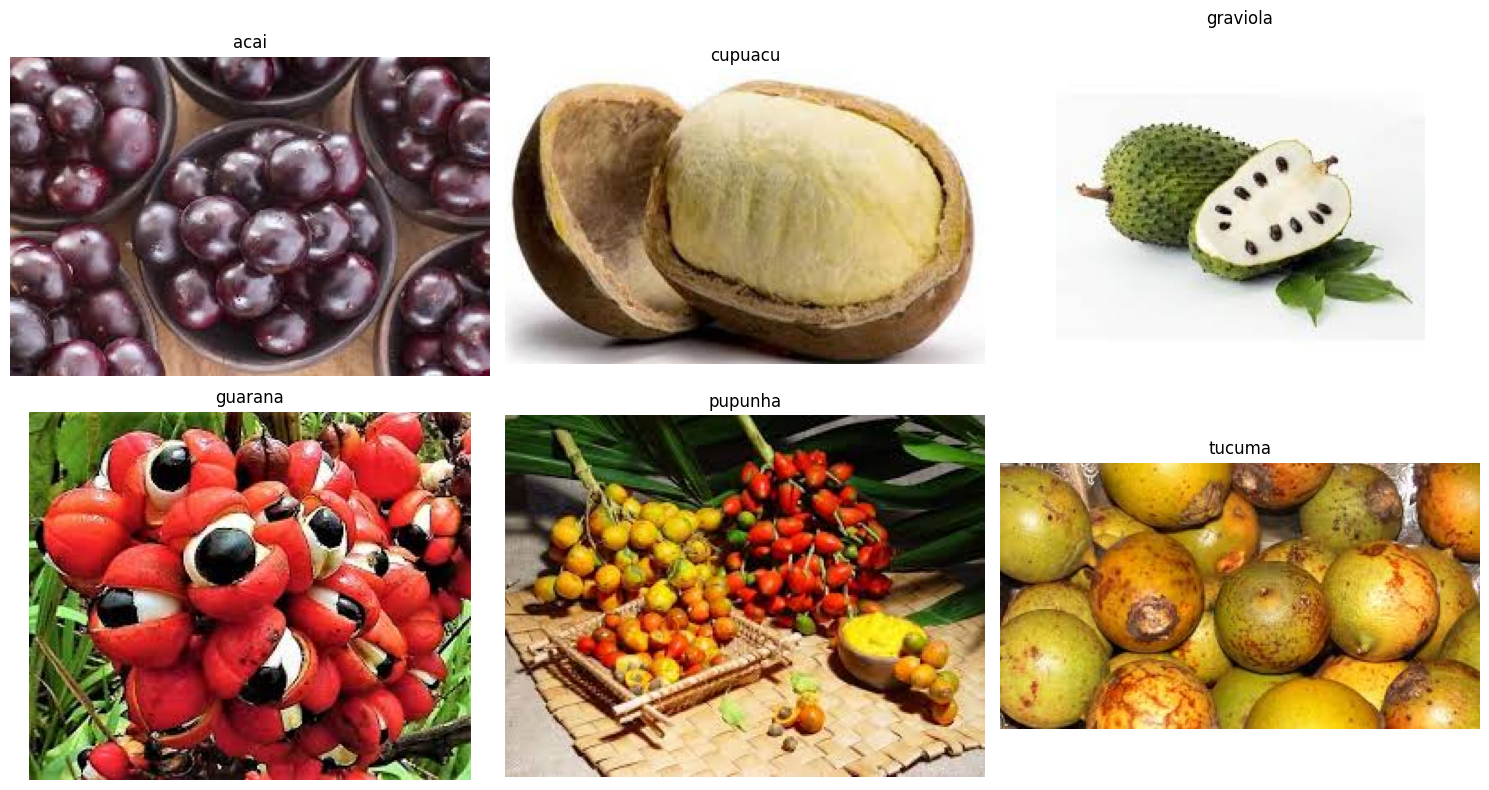

In [2]:
import random
import matplotlib.pyplot as plt
from PIL import Image # Make sure PIL.Image is also imported if used directly
import os

class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", class_names)

sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    chosen = random.choice(images)
    sample_images.append((class_name, os.path.join(class_path, chosen)))

plt.figure(figsize=(15, 8))

for i, (class_name, img_path) in enumerate(sample_images):
    plt.subplot(2, 3, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 1: Check corrupted images

In [3]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError, OSError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


# Task 2: Load and preprocess image data

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

rescale = tf.keras.layers.Rescaling(1./255)
train_dir = "/content/drive/MyDrive/AI ml/Data/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/AI ml/Data/FruitinAmazon/test"

# Verify paths
import os
print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Train exists: True
Test exists: True
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Task 3: Build the CNN model

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(class_names)

model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the model

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train the model

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_fruit_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.1969 - loss: 285.5211
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 847ms/step - accuracy: 0.1667 - loss: 294.9657 - val_accuracy: 0.0000e+00 - val_loss: 327.4437
Epoch 2/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1875 - loss: 208.5970
Epoch 2: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2222 - loss: 116.9614 - val_accuracy: 0.0000e+00 - val_loss: 42.1039
Epoch 3/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3125 - loss: 13.3759
Epoch 3: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2917 - loss: 8.4636 - val_accuracy: 0.0000e+00 - val_loss: 2.7455
Epoch 4/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4375 - loss: 1.4626
Epoch 4: val_accuracy improved from 0.00000 to 0.61111, saving model to best_fruit_model.h5



Epoch 4: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5417 - loss: 1.3117 - val_accuracy: 0.6111 - val_loss: 1.4913
Epoch 5/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6250 - loss: 1.2273
Epoch 5: val_accuracy improved from 0.61111 to 0.83333, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7083 - loss: 0.9988 - val_accuracy: 0.8333 - val_loss: 0.8406
Epoch 6/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8750 - loss: 0.6261
Epoch 6: val_accuracy improved from 0.83333 to 0.94444, saving model to best_fruit_model.h5



Epoch 6: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8611 - loss: 0.5446 - val_accuracy: 0.9444 - val_loss: 0.3985
Epoch 7/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9375 - loss: 0.2832
Epoch 7: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9583 - loss: 0.2240 - val_accuracy: 0.9444 - val_loss: 0.2117
Epoch 8/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 0.1104
Epoch 8: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0561 - val_accuracy: 0.9444 - val_loss: 0.2802
Epoch 9/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0483
Epoch 9: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0148 - val_accuracy: 0.7778 - val_loss: 0.4577
Epoch 10/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0077
Epo

# Plot training and validation graphs

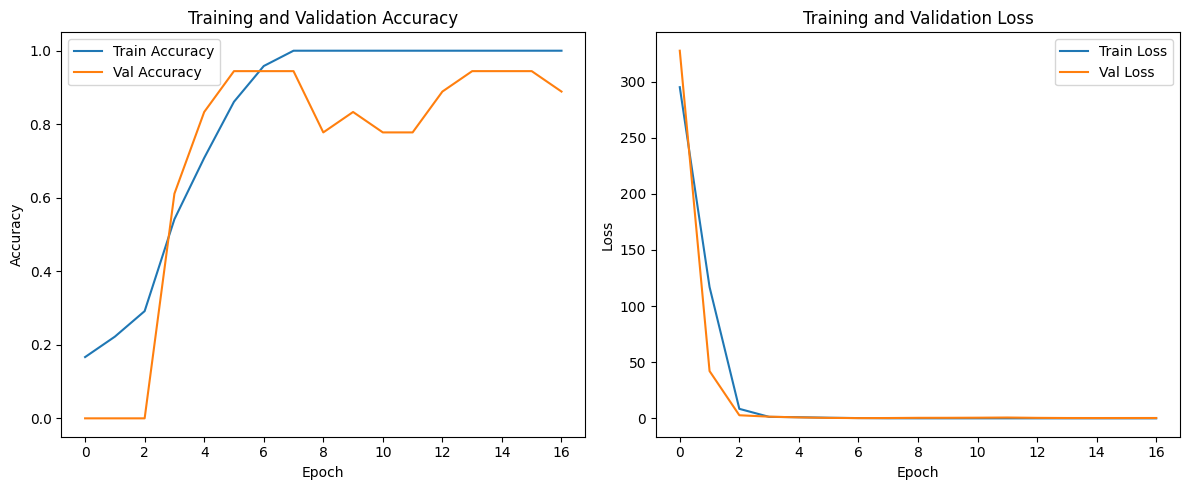

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Task 5: Evaluate on test set

In [15]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step - accuracy: 0.4000 - loss: 1.5857
Test Loss: 1.5856895446777344
Test Accuracy: 0.4000000059604645


# Task 6: Save and load the model

In [16]:
model.save("fruit_classifier_model.h5")
print("Model saved successfully.")

Model saved successfully.


In [17]:
loaded_model = keras.models.load_model("fruit_classifier_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step - accuracy: 0.4000 - loss: 1.5857
Loaded Model Test Loss: 1.5856895446777344
Loaded Model Test Accuracy: 0.4000000059604645


# Task 7: Predictions and classification report

In [18]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1);

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.67      0.40      0.50         5
     guarana       0.50      0.40      0.44         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.25      0.80      0.38         5

    accuracy                           0.40        30
   macro avg       0.35      0.40      0.34        30
weighted avg       0.35      0.40      0.34        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
